## Visualizing the results of prediction interval models

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from pyhere import here

### First, I'll look for counts of crossing over (median prediction outside quantile range)

In [ ]:
for response in ["L_BOL"]:
    full_data = pd.read_csv(here('predictions', f'{response}_final_predictions.csv'))
    print(response)
    data = full_data[full_data['0.025_pred'] > full_data['median_pred']]
    print(data)
    data = full_data[full_data['median_pred'] > full_data['0.975_pred']]
    print(data)
    data = full_data[full_data['0.025_pred'] > full_data['mean_pred']]
    print(data)
    data = full_data[full_data['mean_pred'] > full_data['0.975_pred']]
    print(data)

    

L_BOL
          YB  mean_pred  0.025_pred  median_pred  0.975_pred
161    472.0  261.60043  270.748700   247.044190   545.53467
240    715.0   87.97328   45.046494    27.431747  2561.57180
355   1130.0  530.64594  579.737300   558.637900  3737.68260
435   1408.0  227.63750  218.182040   216.035960   515.12230
1663  4539.0  909.23530  792.908140   760.716060  1494.65890
          YB    mean_pred  0.025_pred  median_pred   0.975_pred
234    696.0    1231.8595    508.7125    1552.6002    1531.9624
588   1934.0   26909.0060   1529.5630   17294.4300   15435.7810
1563  4189.0  116330.9140  50537.2200  136359.8300  134850.1200
2094  5873.0    7600.3770   2053.8267    8860.8540    8586.9400
          YB   mean_pred  0.025_pred  median_pred  0.975_pred
161    472.0  261.600430  270.748700   247.044190   545.53467
355   1130.0  530.645940  579.737300   558.637900  3737.68260
1151  3087.0    0.816335    0.896021     1.118821   120.08765
1230  3201.0    0.291525    0.292794     0.607429   160.1355

In [29]:
data = pd.read_csv(here('predictions', 'L_BOL_final_predictions.csv'))
print(data[data['YB'] == 588.0])

Empty DataFrame
Columns: [YB, mean_pred, 0.025_pred, median_pred, 0.975_pred]
Index: []


Interestingly, luminosity was the only one with crossing over.

YB's with crossing over in L_BOL: 472, 696, 715, 1130, 1408, 1934, 3087, 3201, 4189, 4539, 5873
and 1 with also crossing over in the mean: 1934

their indexes: 161, 234, 240, 355, 435, 588, 1151, 1230, 1563, 1663, 2094
index: 588

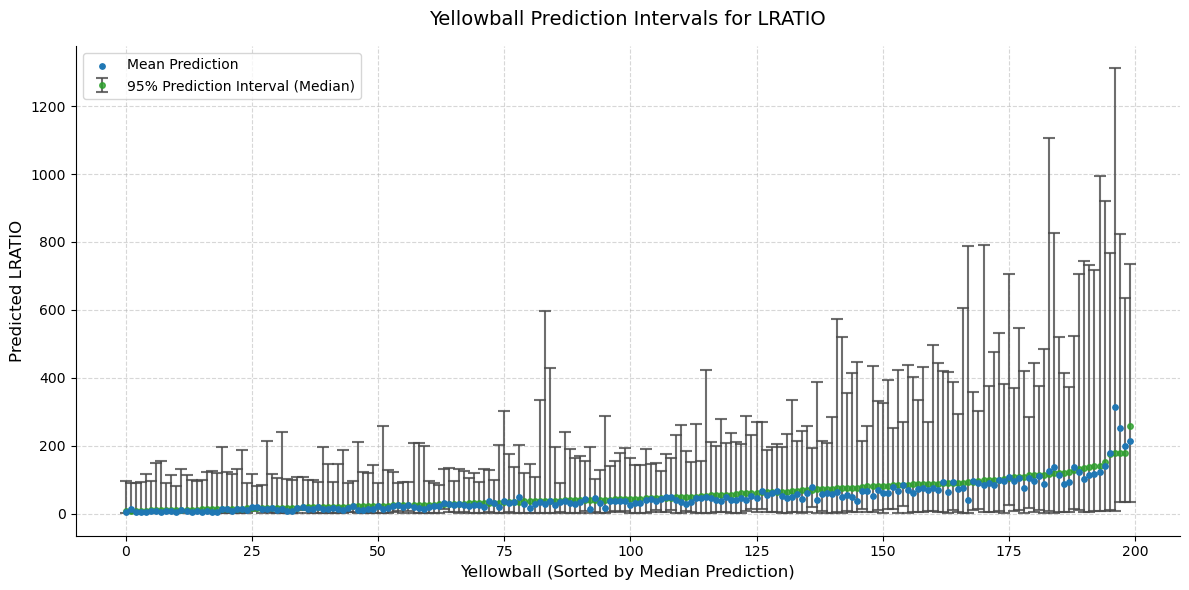

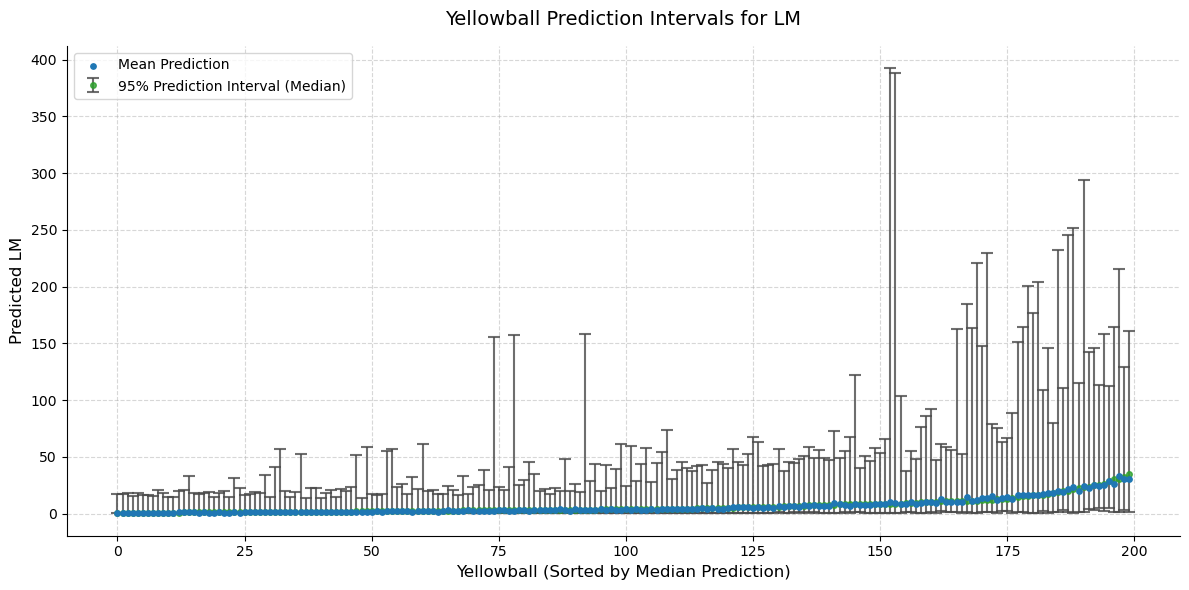

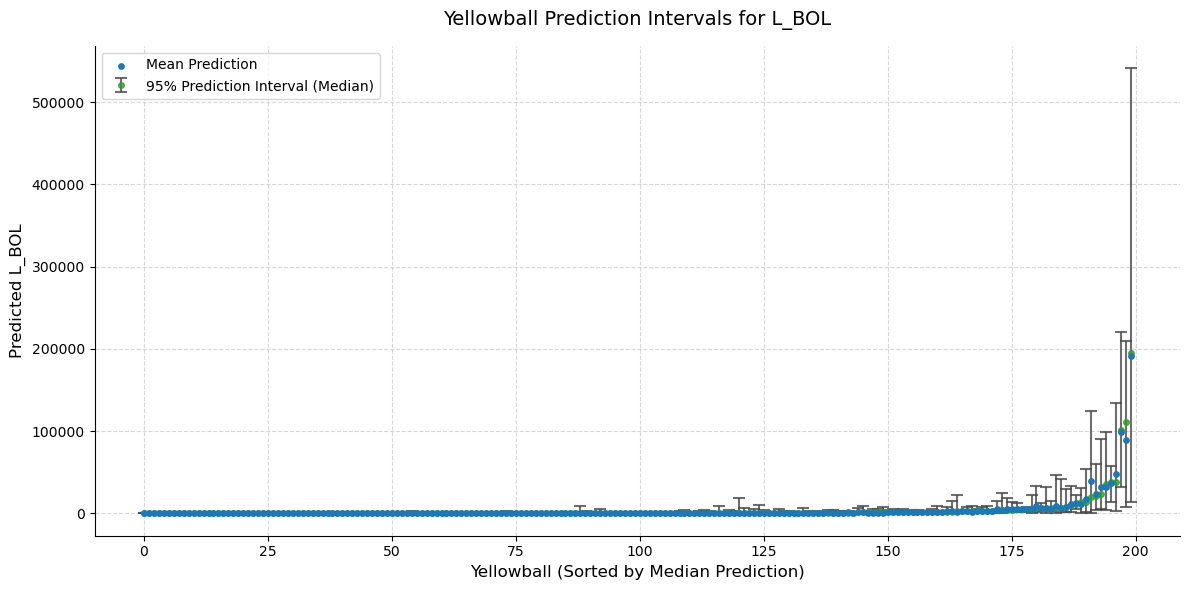

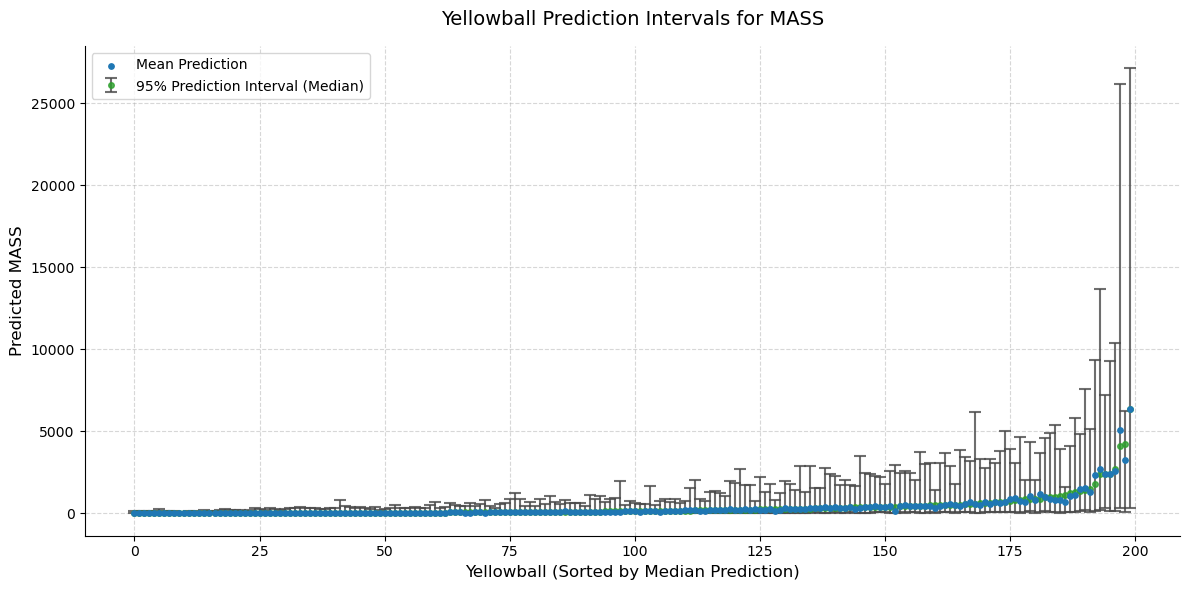

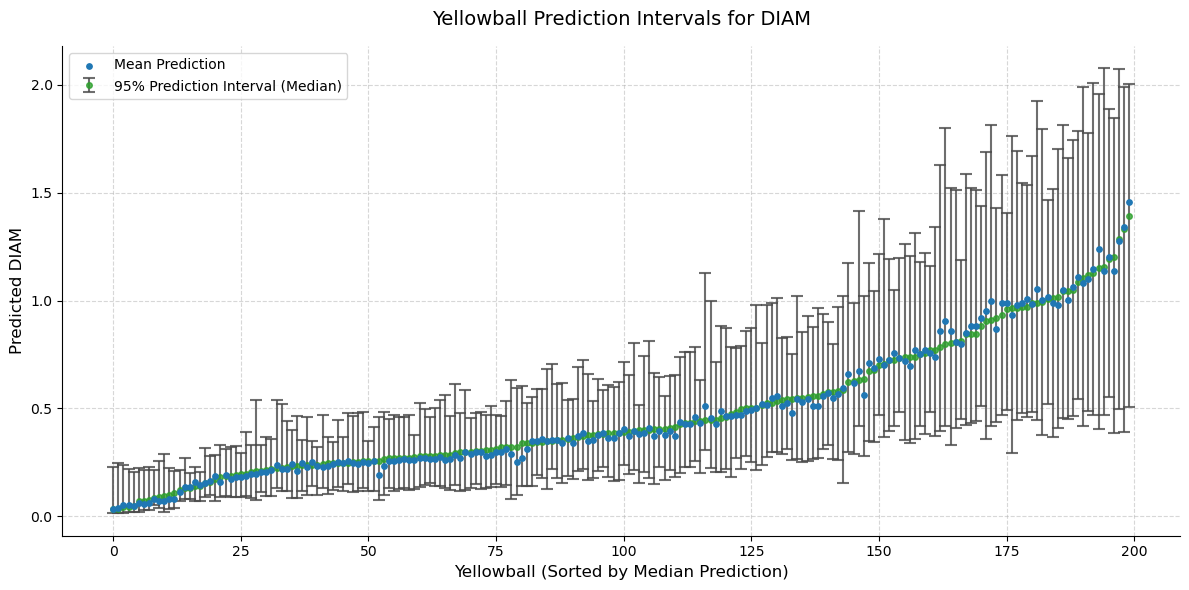

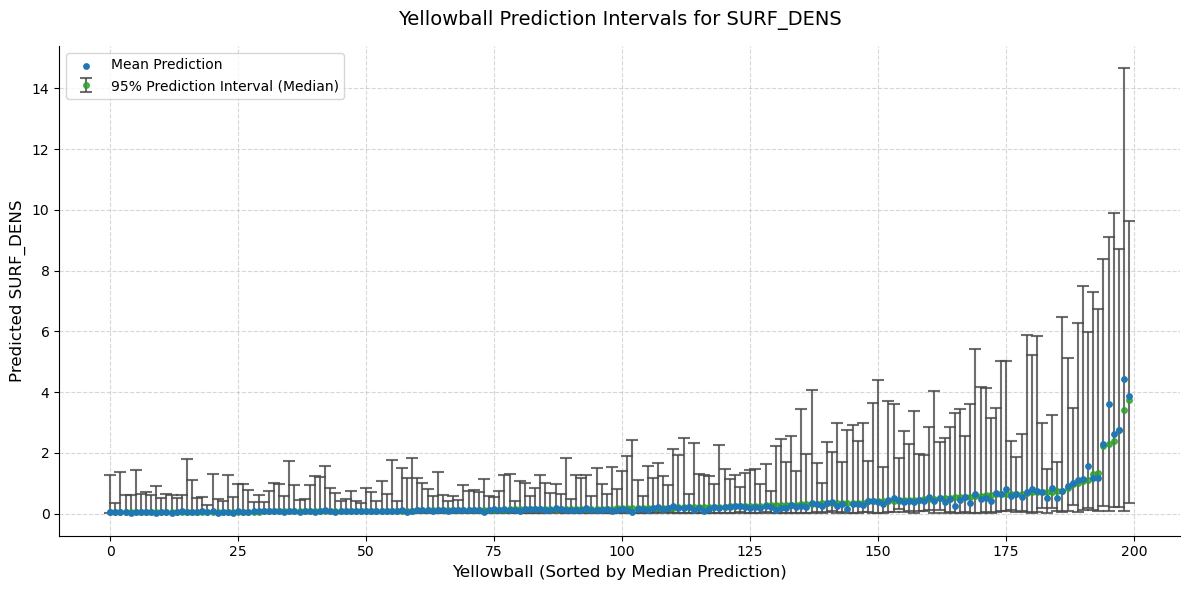

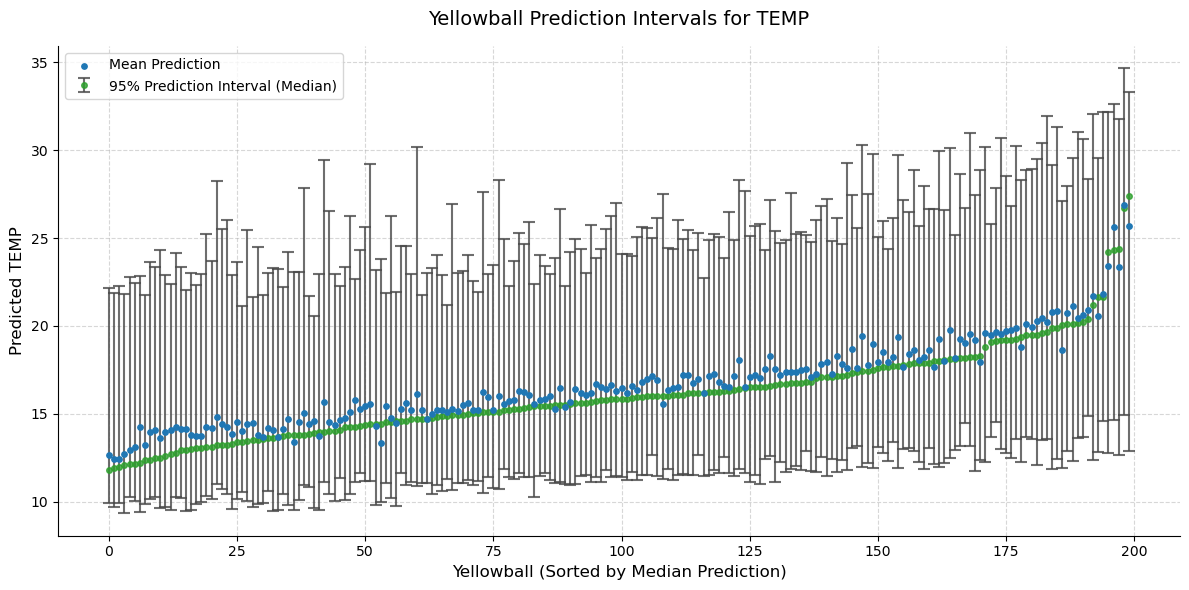

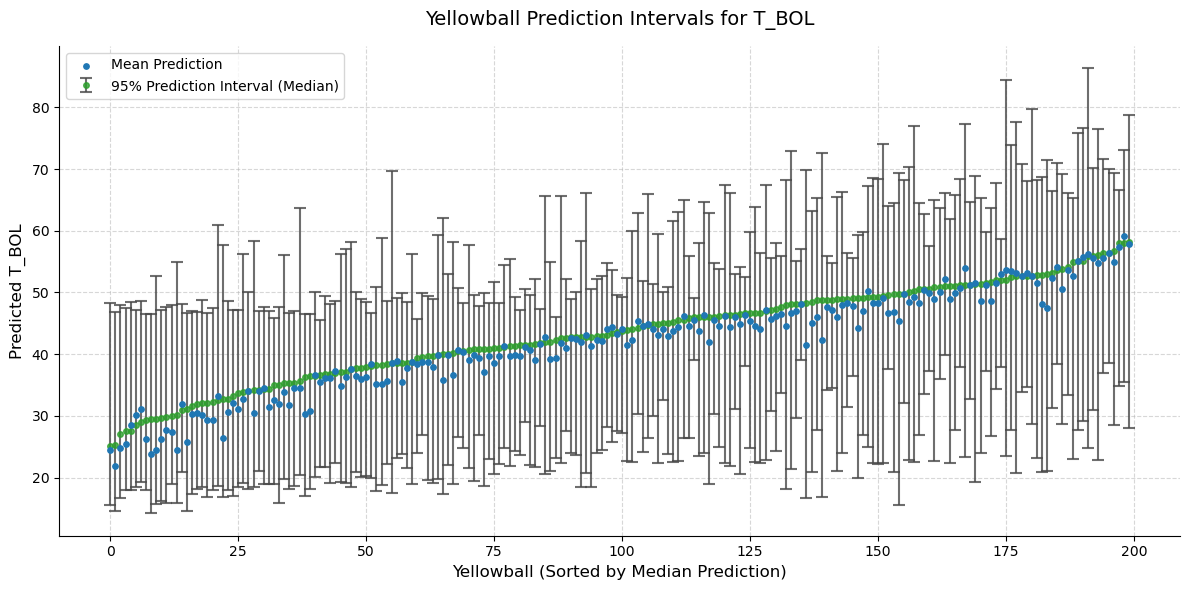

In [ ]:
for response in ["LRATIO", "LM", "L_BOL", "MASS", "DIAM", "SURF_DENS", "TEMP", "T_BOL"]:
    data = pd.read_csv(here('predictions', f'{response}_final_predictions.csv'))

    graphing_sample = data.sample(n=200).sort_values(by='median_pred').reset_index(drop=True)

    error_high = graphing_sample['0.975_pred'] - graphing_sample['median_pred']
    error_low = graphing_sample['median_pred'] - graphing_sample['0.025_pred']

    asymmetric_error = [error_low, error_high]
    predictions = graphing_sample['median_pred']

    fig, ax = plt.subplots(figsize=(12, 6))

    plt.errorbar(
    x=graphing_sample.index, 
    y=predictions, 
    yerr=asymmetric_error, 
    fmt='o',             
    markersize=4,
    color='#2CA02C',     # Clear, distinct blue for the median
    ecolor='#4A4A4A',    # Keeping the bars themselves light grey so they don't overpower
    elinewidth=1.5,
    capsize=4,           # Increased from 0 to make the ends visible
    capthick=1.5,        # Added thickness specifically to the caps
    alpha=0.8,
    label='95% Prediction Interval (Median)'
    )
    
    plt.scatter(
    x=graphing_sample.index,
    y=graphing_sample['mean_pred'],
    color='#1F77B4',     # Clear, distinct green for the mean
    s=15, 
    zorder=3,            
    label='Mean Prediction'
    )

    
    ax.set_title(f'Yellowball Prediction Intervals for {response}', fontsize=14, pad=15)
    ax.set_xlabel('Yellowball (Sorted by Median Prediction)', fontsize=12)
    ax.set_ylabel(f'Predicted {response}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

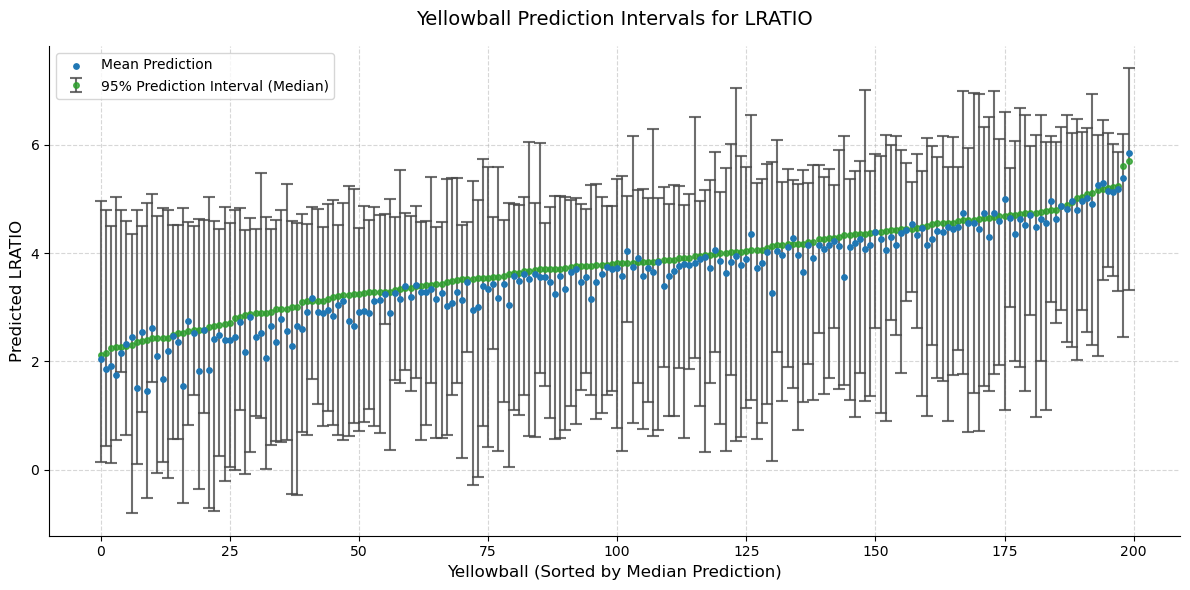

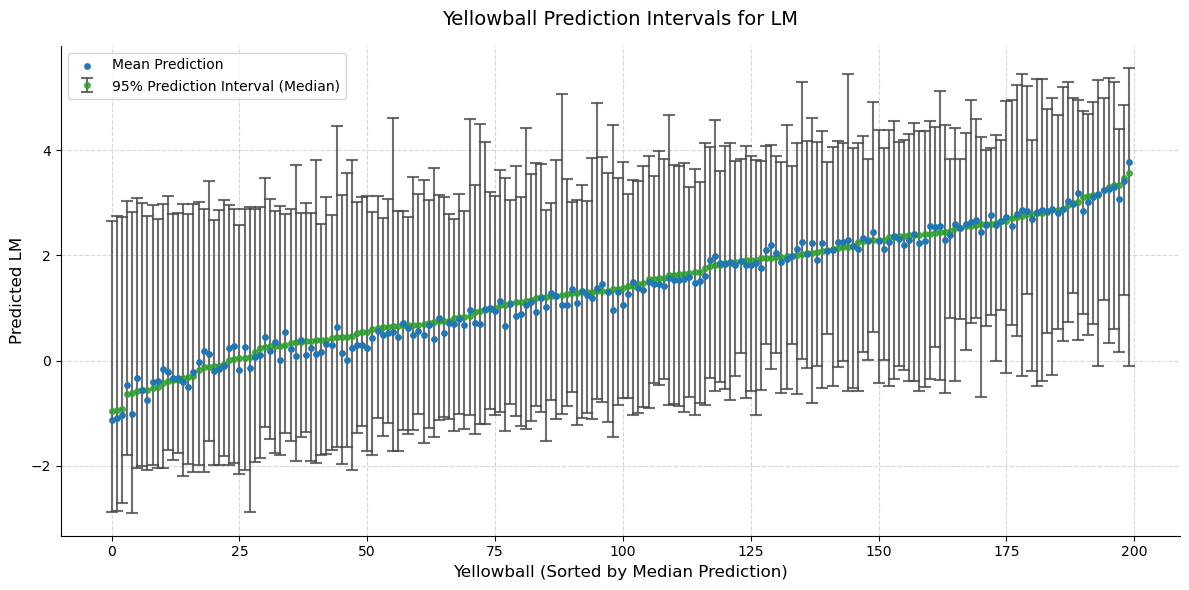

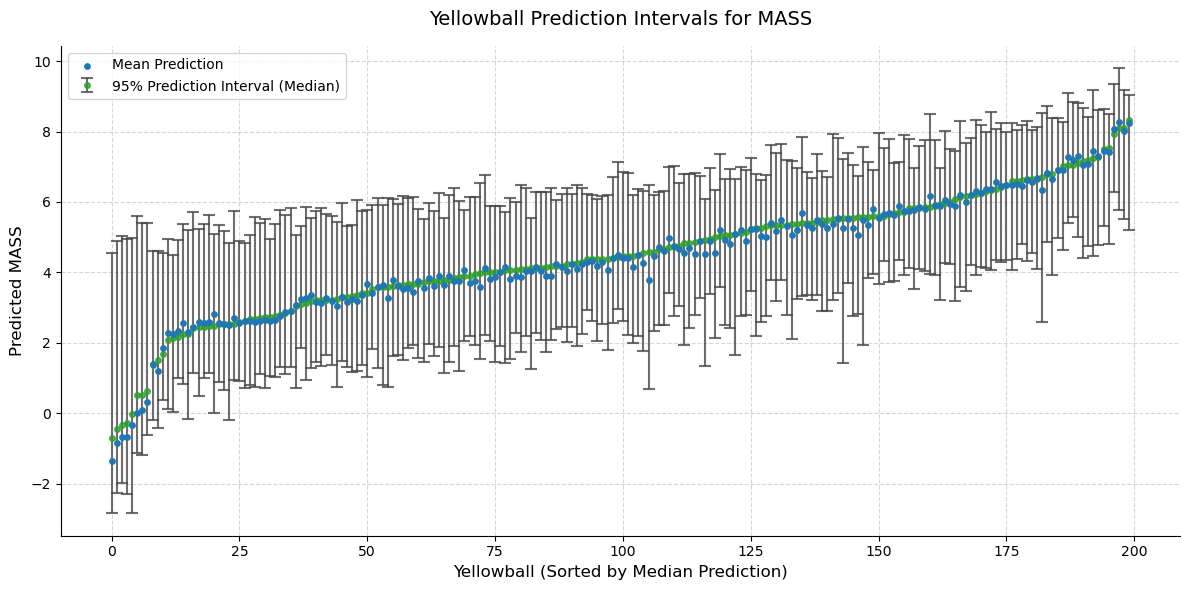

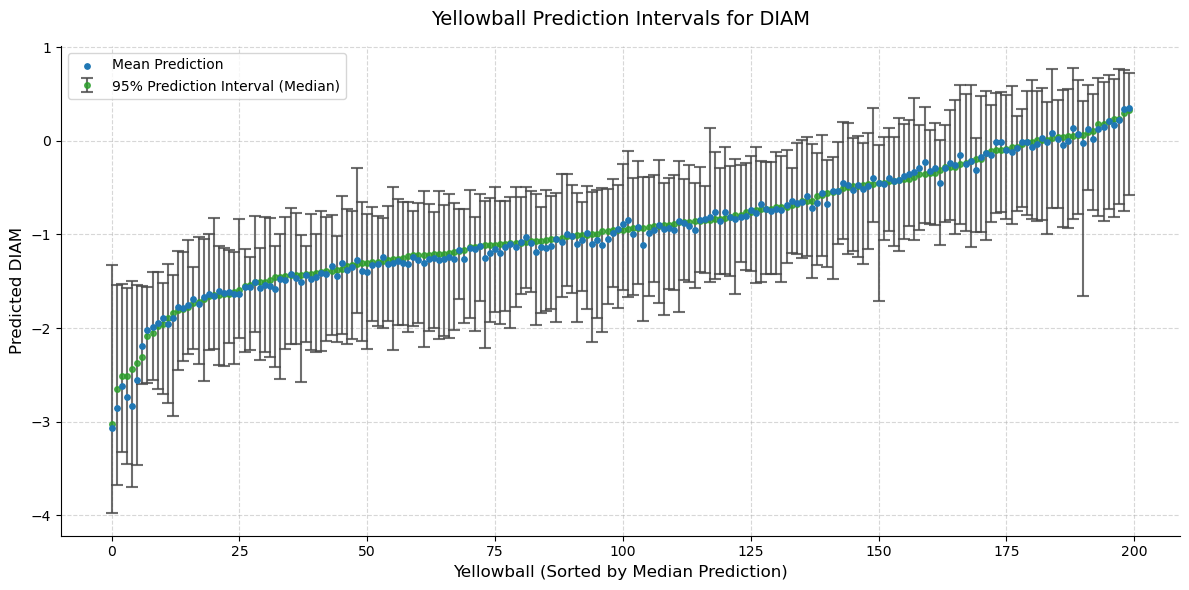

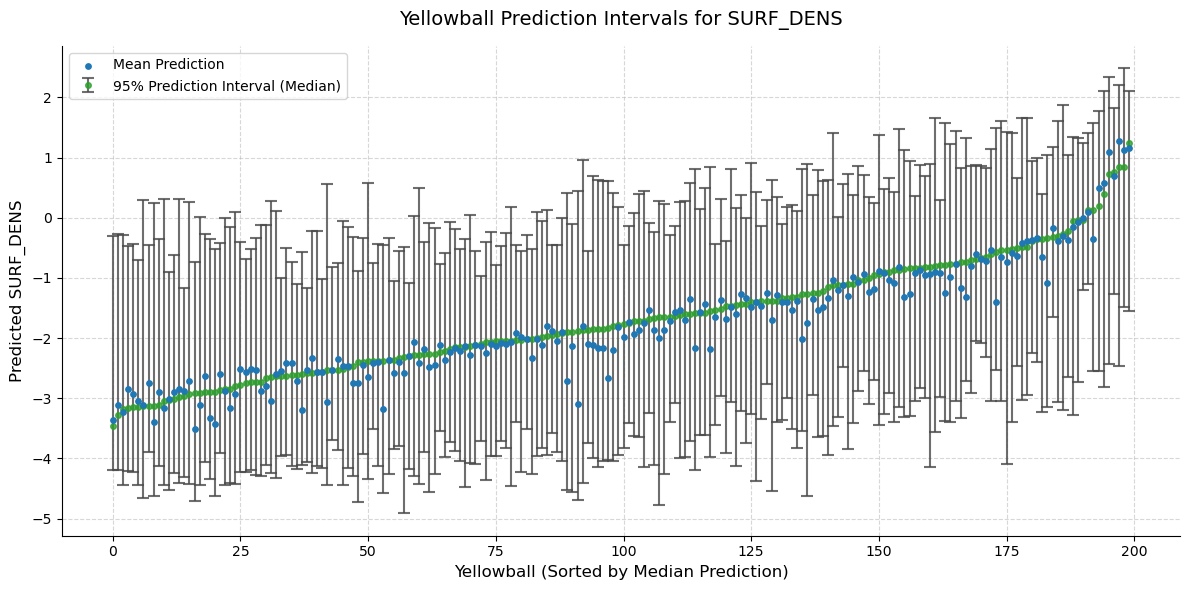

In [17]:
for response in ["LRATIO", "LM", "MASS", "DIAM", "SURF_DENS"]:
    data = pd.read_csv(here('predictions', f'{response}_final_predictions.csv'))

    graphing_sample = data.sample(n=200).sort_values(by='median_pred').reset_index(drop=True)

    graphing_sample=np.log(graphing_sample)

    error_high = graphing_sample['0.975_pred'] - graphing_sample['median_pred']
    error_low = graphing_sample['median_pred'] - graphing_sample['0.025_pred']

    asymmetric_error = [error_low, error_high]
    predictions = graphing_sample['median_pred']

    fig, ax = plt.subplots(figsize=(12, 6))

    plt.errorbar(
    x=graphing_sample.index, 
    y=predictions, 
    yerr=asymmetric_error, 
    fmt='o',             
    markersize=4,
    color='#2CA02C',     # Clear, distinct blue for the median
    ecolor='#4A4A4A',    # Keeping the bars themselves light grey so they don't overpower
    elinewidth=1.5,
    capsize=4,           # Increased from 0 to make the ends visible
    capthick=1.5,        # Added thickness specifically to the caps
    alpha=0.8,
    label='95% Prediction Interval (Median)'
    )
    
    plt.scatter(
    x=graphing_sample.index,
    y=graphing_sample['mean_pred'],
    color='#1F77B4',     # Clear, distinct green for the mean
    s=15, 
    zorder=3,            
    label='Mean Prediction'
    )

    
    ax.set_title(f'Yellowball Prediction Intervals for {response}', fontsize=14, pad=15)
    ax.set_xlabel('Yellowball (Sorted by Median Prediction)', fontsize=12)
    ax.set_ylabel(f'Predicted {response}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

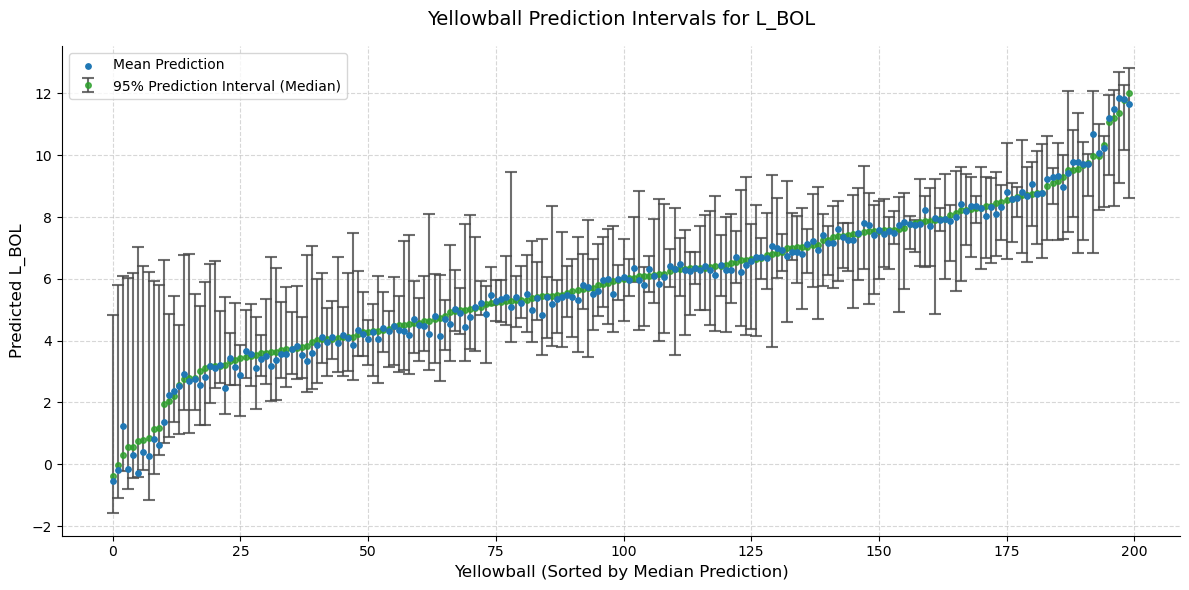

In [30]:
response = 'L_BOL'
data = pd.read_csv(here('predictions', f'{response}_final_predictions.csv'))
data = data.drop([161, 234, 240, 355, 435, 588, 1151, 1230, 1563, 1663, 2094])

graphing_sample = data.sample(n=200).sort_values(by='median_pred').reset_index(drop=True)

graphing_sample=np.log(graphing_sample)

error_high = graphing_sample['0.975_pred'] - graphing_sample['median_pred']
error_low = graphing_sample['median_pred'] - graphing_sample['0.025_pred']

asymmetric_error = [error_low, error_high]
predictions = graphing_sample['median_pred']

fig, ax = plt.subplots(figsize=(12, 6))

plt.errorbar(
x=graphing_sample.index, 
y=predictions, 
yerr=asymmetric_error, 
fmt='o',             
markersize=4,
color='#2CA02C',     # Clear, distinct blue for the median
ecolor='#4A4A4A',    # Keeping the bars themselves light grey so they don't overpower
elinewidth=1.5,
capsize=4,           # Increased from 0 to make the ends visible
capthick=1.5,        # Added thickness specifically to the caps
alpha=0.8,
label='95% Prediction Interval (Median)'
)

plt.scatter(
x=graphing_sample.index,
y=graphing_sample['mean_pred'],
color='#1F77B4',     # Clear, distinct green for the mean
s=15, 
zorder=3,            
label='Mean Prediction'
)


ax.set_title(f'Yellowball Prediction Intervals for {response}', fontsize=14, pad=15)
ax.set_xlabel('Yellowball (Sorted by Median Prediction)', fontsize=12)
ax.set_ylabel(f'Predicted {response}', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left')

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()